# Training Model

### Goal

- In this notebook, text vectorization, model training, and model evaluation are performed.
- TF-IDF vectorization is used to convert text into numerical features.
- Logistic Regression and Multinomial Naive Bayes models are trained and evaluated for sentiment classification.
- The models are evaluated using accuracy score and confusion matrix.

### Importing Data

In [149]:
import pandas as pd

In [150]:
df=pd.read_csv("../data/cleaned.csv",index_col=0)

In [151]:
df.head()

,review,clean_review,sentiment
0,In Panic In The Streets Richard Widmark plays ...,panic streets richard widmark play us navy doc...,positive
1,If you ask me the first one was really better ...,ask first one really better one look sarah g r...,negative
2,I am a big fan a Faerie Tale Theatre and Ive s...,big fan faerie tale theatre ive seen one best ...,positive
3,I just finished reading a book about Dillinger...,finished reading book dillinger movie horribly...,negative
4,Greg Davis and Bryan Daly take some crazed sta...,greg davis bryan daly take crazed statement te...,negative


## TF-IDF

In [152]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [153]:
tfidf=TfidfVectorizer(max_features=6000,ngram_range=(1,2))
X=tfidf.fit_transform(df['clean_review'])

In [154]:
y=df['sentiment']

## Train Test split

In [155]:
from sklearn.model_selection import train_test_split

In [156]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.1)

In [157]:
print(X_train.shape, y_train.shape)

(22500, 6000) (22500,)


## Model Trainig

In [158]:
from sklearn.linear_model import LogisticRegression

In [159]:
lr_model=LogisticRegression()

In [235]:
lr_model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [187]:
y_pred=lr_model.predict(X_test)

In [188]:
y_pred[0]

'positive'

In [189]:
y_test.iloc[0]

'positive'

## Navies bayes

In [216]:
from sklearn.naive_bayes import MultinomialNB

In [217]:
nb_model=MultinomialNB()

In [233]:
nb_model.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [219]:
nb_y_pred=nb_model.predict(X_test)

In [220]:
nb_y_pred[0]

np.str_('positive')

In [221]:
y_test.iloc[0]

'positive'

## Model Save

In [170]:
import joblib
joblib.dump(lr_model,'../models/lr_model.pkl')

['../models/lr_model.pkl']

In [ ]:
joblib.dump(nb_model,'../models/nb_models.pkl')

['../models/nb_models.pkl']

In [236]:
joblib.dump(tfidf,'../models/tfidf_vectorizer.pkl')

['../models/tfidf_vectorizer.pkl']

## Unseen data For testing

In [172]:
test_df=pd.read_csv('../data/test.csv',index_col=0)

In [173]:
from src.preprocessing import preprocessing

In [174]:
test_df['cleaned_review']=test_df['review'].apply(preprocessing)

In [175]:
test_df.head()

,review,sentiment,cleaned_review
0,"When I was a kid, I loved ""Tiny Toons"". I espe...",positive,kid loved tiny toon especially loved tiny toon...
1,"The setup for ""Nature of the Beast"" is ingenio...",negative,setup nature beast ingeniously simple fraught ...
2,I do not have much to say than this is a great...,positive,not much say great finish story people said no...
3,Extremely formulaic with cosmic-sized logic ho...,negative,extremely formulaic cosmicsized logic hole pre...
4,I actually liked certain things about this gam...,negative,actually liked certain thing game loved first ...


In [176]:
x=test_df['cleaned_review'][0]
x=tfidf.transform([x])

### Logistic model testing

In [177]:
lr_y_pred= lr_model.predict(x)

In [178]:
lr_y_pred

array(['positive'], dtype=object)

In [179]:
test_df['sentiment'][0]

'positive'

### Navie Bayes model testing

In [213]:
y_pred_nb=nb_model.predict(x)

In [214]:
y_pred_nb

array(['positive'], dtype='<U8')

In [215]:
test_df['sentiment'][0]

'positive'

## Model Evaluation 

### Logistic regressing 

In [202]:
from sklearn.metrics import  classification_report, ConfusionMatrixDisplay,confusion_matrix

In [203]:
lr_class=classification_report(y_pred,y_test)

In [204]:
print(lr_class)

              precision    recall  f1-score   support

    negative       0.89      0.90      0.89      1223
    positive       0.90      0.89      0.90      1277

    accuracy                           0.89      2500
   macro avg       0.89      0.89      0.89      2500
weighted avg       0.89      0.89      0.89      2500



Text(0.5, 1.0, 'Confusion Matrix for Logistic regression')

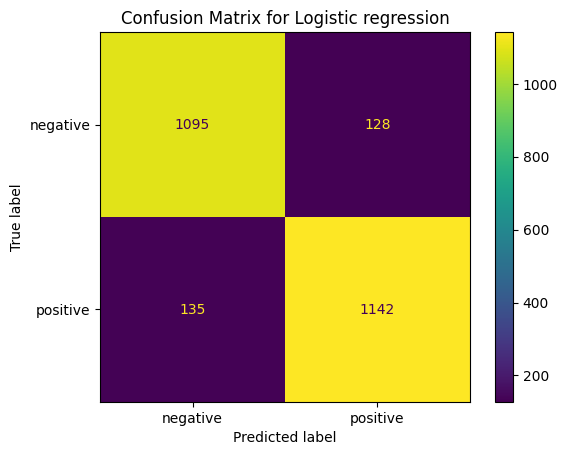

In [227]:
import matplotlib.pyplot as plt
cm=confusion_matrix(y_pred,y_test)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=lr_model.classes_)
disp.plot()
plt.title('Confusion Matrix for Logistic regression')

In [228]:
nb_class=classification_report(nb_y_pred,y_test)

In [229]:
print(nb_class)

              precision    recall  f1-score   support

    negative       0.87      0.86      0.87      1234
    positive       0.87      0.87      0.87      1266

    accuracy                           0.87      2500
   macro avg       0.87      0.87      0.87      2500
weighted avg       0.87      0.87      0.87      2500



In [230]:
nb_cm=confusion_matrix(nb_y_pred,y_test)
nb_disp=ConfusionMatrixDisplay(confusion_matrix=nb_cm,display_labels=nb_model.classes_)

Text(0.5, 1.0, 'Confusion matrix for Navie Bayes')

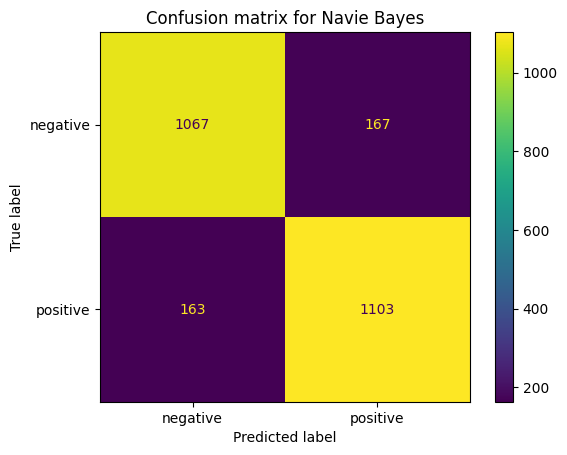

In [231]:
nb_disp.plot()
plt.title("Confusion matrix for Navie Bayes")

## Conclusion
- In this notebook, the text data was preprocessed, vectorized using TF-IDF, and used for sentiment classification.
- Multiple machine learning models including Logistic Regression and Naive Bayes were trained and evaluated.
- Logistic Regression performed better compared to Multinomial Naive Bayes based on accuracy and confusion matrix evaluation.
- The trained model was also tested on unseen data from the separate `test.csv` dataset, where it generalized well for sentiment prediction.